# Data Inspection & Exploratory Data Analysis

> **Objective:** Predict EV charging station demand using historical usage data with classical machine learning models.
> **Project:** EV Charging Demand Prediction (Milestone 1)  
> **Dataset:** UrbanEV — Shenzhen, China  
> **Period:** September 1, 2022 – February 28, 2023  
> **Scope:** 275 administrative zones, 1,362 charging stations, 17,532 charging piles

| Item | Detail |
|------|--------|
| **Dataset** | UrbanEV, Shenzhen China, Sep 2022 – Feb 2023 |
| **Scope** | 275 administrative zones, 1362 stations, 17532 charging piles |
| **Metadeta** | 6 hourly time-series files + zone/station metadata |
| **Purpose** | Understand the data before building models |

## Import Required Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set seaborn theme
sns.set_theme(style="darkgrid", palette="viridis")

print("Libraries loaded!")

Libraries loaded!


## **Exploratory Data Analysis (EDA)**

## 1. Loading Raw Datasets


In [2]:
DATA_DIR = Path("../data/raw")
HOURLY = DATA_DIR / "charge_1hour"

# Load all 6 hourly time-series files (wide format: time × 275 zones)
occupancy = pd.read_csv(HOURLY / "occupancy.csv")
volume = pd.read_csv(HOURLY / "volume.csv")
duration = pd.read_csv(HOURLY / "duration.csv")
e_price = pd.read_csv(HOURLY / "e_price.csv")
s_price = pd.read_csv(HOURLY / "s_price.csv")
volume_11kw = pd.read_csv(HOURLY / "volume-11kw.csv")

# Load metadata
zone_info = pd.read_csv(DATA_DIR / "zone-information.csv")
station_info = pd.read_csv(DATA_DIR / "station_information.csv")

datasets = {
    "occupancy": occupancy,
    "volume": volume,
    "duration": duration,
    "e_price": e_price,
    "s_price": s_price,
    "volume_11kw": volume_11kw,
    "zone_info": zone_info,
    "station_info": station_info,
}

print("All datasets loaded successfully!")

All datasets loaded successfully!


## 2. Data Structure Overview

Inspect Shapes & Date Range

In [3]:
# All hourly files share the same structure
print("Columns (first 10):", occupancy.columns[:10].tolist())
print("Number of zones:", len(occupancy.columns) - 1)  # minus 'time' column

occupancy['time'] = pd.to_datetime(occupancy['time'])
print(f"Date range: {occupancy['time'].min()} → {occupancy['time'].max()}")
print(f"Total timestamps: {len(occupancy)}")
print(f"Expected hours in 6 months: {181 * 24}")  # Sep–Feb = ~181 days

Columns (first 10): ['time', '102', '104', '105', '106', '107', '108', '109', '110', '111']
Number of zones: 275
Date range: 2022-09-01 00:00:00 → 2023-02-28 23:00:00
Total timestamps: 4344
Expected hours in 6 months: 4344


Preview Datasets

In [4]:
print("Occupancy (%)")
display(occupancy.head(3))

print("\nVolume (kWh)")
display(volume.head(3))

print("\nZone Information")
display(zone_info.head())

print("\nStation Information")
display(station_info.head())

Occupancy (%)


,time,102,104,105,106,107,108,109,110,111,...,1156,1159,1162,1163,1164,1166,1167,1168,1172,1173
0,2022-09-01 00:00:00,17.0,1.0,15.0,54.0,23.0,13.0,11.0,6.0,20.0,...,10.0,31.0,9.0,2.0,45.0,26.0,183.0,17.0,2.0,10.0
1,2022-09-01 01:00:00,16.0,1.0,19.0,50.0,25.0,13.0,7.0,12.0,19.0,...,7.0,31.0,8.0,1.0,42.0,25.0,174.0,12.0,2.0,9.0
2,2022-09-01 02:00:00,16.0,1.0,20.0,44.0,24.0,16.0,12.0,6.0,21.0,...,7.0,38.0,9.0,2.0,48.0,24.0,196.0,13.0,2.0,12.0



Volume (kWh)


,time,102,104,105,106,107,108,109,110,111,...,1156,1159,1162,1163,1164,1166,1167,1168,1172,1173
0,2022-09-01 00:00:00,56.291667,11.083333,60.375000,78.750000,90.125000,71.458333,58.916667,40.250000,65.625000,...,46.666667,134.458333,43.458333,11.083333,224.875000,168.583333,9126.75,123.666667,6.125,71.750000
1,2022-09-01 01:00:00,50.458333,9.333333,72.625000,81.666667,100.333333,76.708333,51.916667,43.166667,67.666667,...,39.666667,151.958333,50.458333,9.916667,224.583333,168.875000,9111.00,111.416667,5.250,65.333333
2,2022-09-01 02:00:00,55.708333,12.833333,73.208333,89.250000,94.500000,75.833333,58.333333,43.166667,70.000000,...,46.666667,148.166667,44.333333,11.666667,223.125000,165.083333,6961.50,113.750000,5.250,67.083333



Zone Information


,TAZID,longitude,latitude,charge_count,area,perimeter
0,1066,113.910301,22.521287,40,1.577893e+06,5119.3013
1,1068,113.918680,22.517837,271,1.405269e+06,5460.2638
2,1096,113.919902,22.531428,70,1.074909e+06,4437.0676
3,326,113.931887,22.535775,106,1.963022e+06,6447.5728
4,1085,113.925789,22.521524,59,3.878395e+05,2688.3240



Station Information


,station_id,longitude,latitude,charge_count,TAZID
0,1001,113.784724,22.714121,20,559
1,1002,113.785002,22.725900,22,558
2,1003,113.787971,22.735538,6,558
3,1004,113.788126,22.693449,11,596
4,1006,113.790987,22.731351,10,594


## 3. Missing Value Analysis

In [5]:
for name, df in [
        ("occupancy", occupancy),
        ("volume", volume),
        ("duration", duration),
        ("e_price", e_price),
        ("s_price", s_price)
    ]:
    nulls = df.isnull().sum().sum()
    total = df.size
    print(f"{name:10s} = Missing: {nulls:,} ({nulls / total * 100:.2f}%)")

occupancy  = Missing: 0 (0.00%)
volume     = Missing: 0 (0.00%)
duration   = Missing: 0 (0.00%)
e_price    = Missing: 0 (0.00%)
s_price    = Missing: 0 (0.00%)


## 4. Summary Statistics

In [6]:
occ_values = occupancy.iloc[:, 1:].values.flatten()
vol_values = volume.iloc[:, 1:].values.flatten()
dur_values = duration.iloc[:, 1:].values.flatten()

stats = pd.DataFrame({
    "Occupancy (%)": pd.Series(occ_values).describe(),
    "Volume (kWh)": pd.Series(vol_values).describe(),
    "Duration (hours)": pd.Series(dur_values).describe(),
})
print("Overall Statistics:")
display(stats.round(2))

Overall Statistics:


,Occupancy (%),Volume (kWh),Duration (hours)
count,1194600.00,1194600.00,1194600.00
mean,17.87,261.46,13.11
std,21.01,859.77,17.22
min,0.00,0.00,0.00
25%,5.00,18.67,2.67
50%,11.00,53.67,7.00
75%,23.00,152.58,16.25
max,373.00,16732.50,207.58


## 5. Visualizations

#### Chart 1 — Daily Mean Demand Trend (6 months)

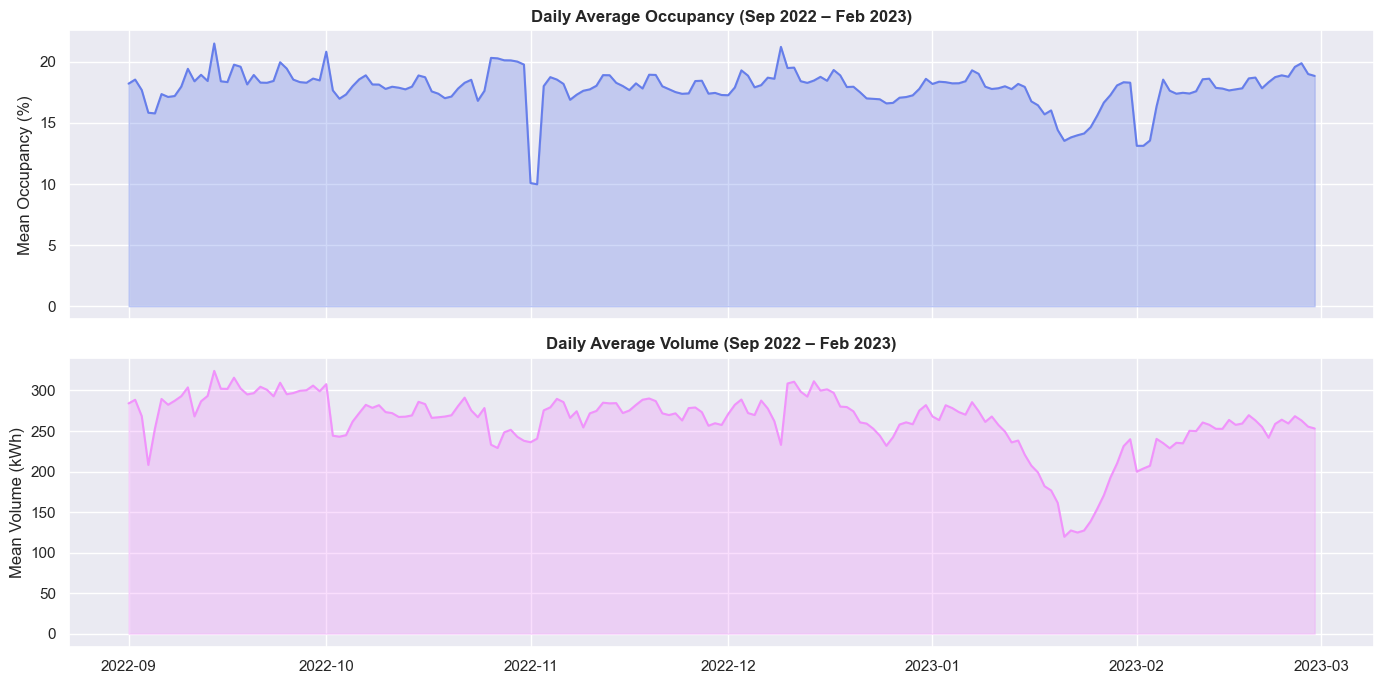

In [7]:
occupancy['time'] = pd.to_datetime(occupancy['time'])
volume['time'] = pd.to_datetime(volume['time'])

daily_occ = occupancy.set_index('time').mean(axis=1).resample('D').mean()
daily_vol = volume.set_index('time').mean(axis=1).resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(daily_occ.index, daily_occ.values, alpha=0.3, color='#667eea')
axes[0].plot(daily_occ.index, daily_occ.values, color='#667eea', linewidth=1.5)
axes[0].set_ylabel("Mean Occupancy (%)")
axes[0].set_title("Daily Average Occupancy (Sep 2022 – Feb 2023)", fontweight='bold')

axes[1].fill_between(daily_vol.index, daily_vol.values, alpha=0.3, color='#f093fb')
axes[1].plot(daily_vol.index, daily_vol.values, color='#f093fb', linewidth=1.5)
axes[1].set_ylabel("Mean Volume (kWh)")
axes[1].set_title("Daily Average Volume (Sep 2022 – Feb 2023)", fontweight='bold')

plt.tight_layout()
plt.show()

#### Chart 2 — Hourly Demand Profile

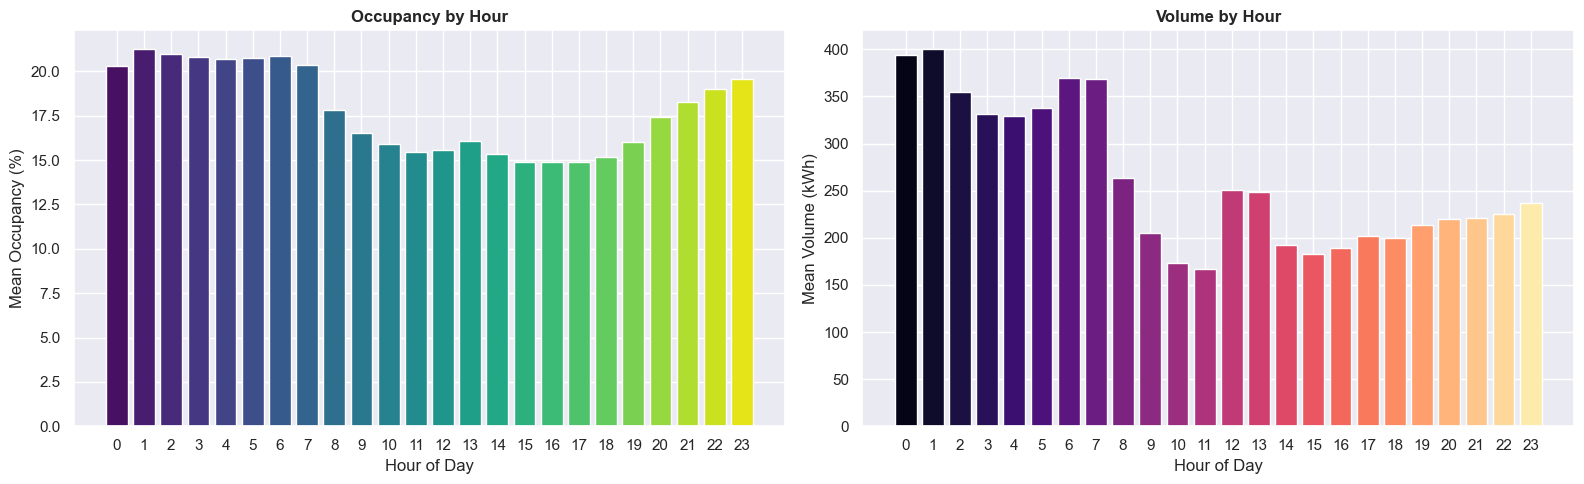

In [8]:
# Melt Dataset
occupancy_long = occupancy.melt(id_vars='time', var_name='zone_id', value_name='occ')
occupancy_long['hour'] = pd.to_datetime(occupancy_long['time']).dt.hour
hourly = occupancy_long.groupby('hour')['occ'].mean()

volume_long = volume.melt(id_vars='time', var_name='zone_id', value_name='vol')
volume_long['hour'] = pd.to_datetime(volume_long['time']).dt.hour
hourly_vol = volume_long.groupby('hour')['vol'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Occupancy by hour
axes[0].bar(hourly.index, hourly.values, color=sns.color_palette("viridis", 24))
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Mean Occupancy (%)")
axes[0].set_title("Occupancy by Hour", fontweight='bold')
axes[0].set_xticks(range(24))

# Volume by hour
axes[1].bar(hourly_vol.index, hourly_vol.values, color=sns.color_palette("magma", 24))
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Mean Volume (kWh)")
axes[1].set_title("Volume by Hour", fontweight='bold')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

#### Chart 3 — Day-of-Week Pattern

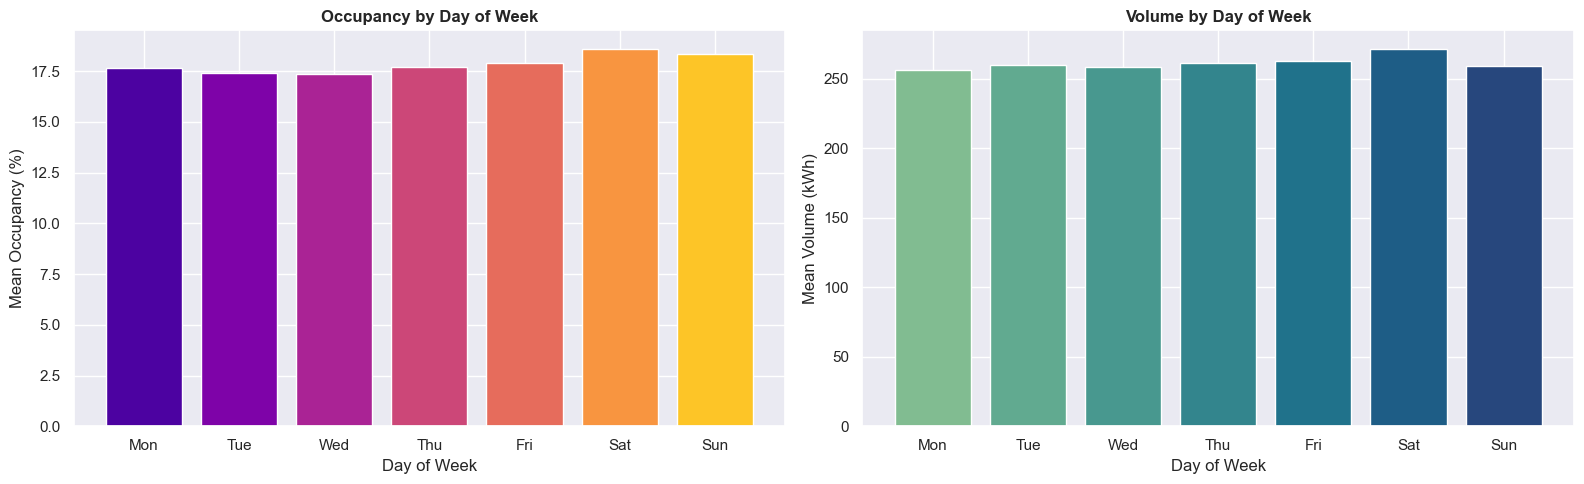

In [9]:
occupancy_long['dow'] = pd.to_datetime(occupancy_long['time']).dt.dayofweek
volume_long['dow'] = pd.to_datetime(volume_long['time']).dt.dayofweek
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekly_occ = occupancy_long.groupby('dow')['occ'].mean()
weekly_vol = volume_long.groupby('dow')['vol'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(dow_labels, weekly_occ.values, color=sns.color_palette("plasma", 7))
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Mean Occupancy (%)")
axes[0].set_title("Occupancy by Day of Week", fontweight='bold')

axes[1].bar(dow_labels, weekly_vol.values, color=sns.color_palette("crest", 7))
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Mean Volume (kWh)")
axes[1].set_title("Volume by Day of Week", fontweight='bold')

plt.tight_layout()
plt.show()

#### Chart 4 — Monthly Trend

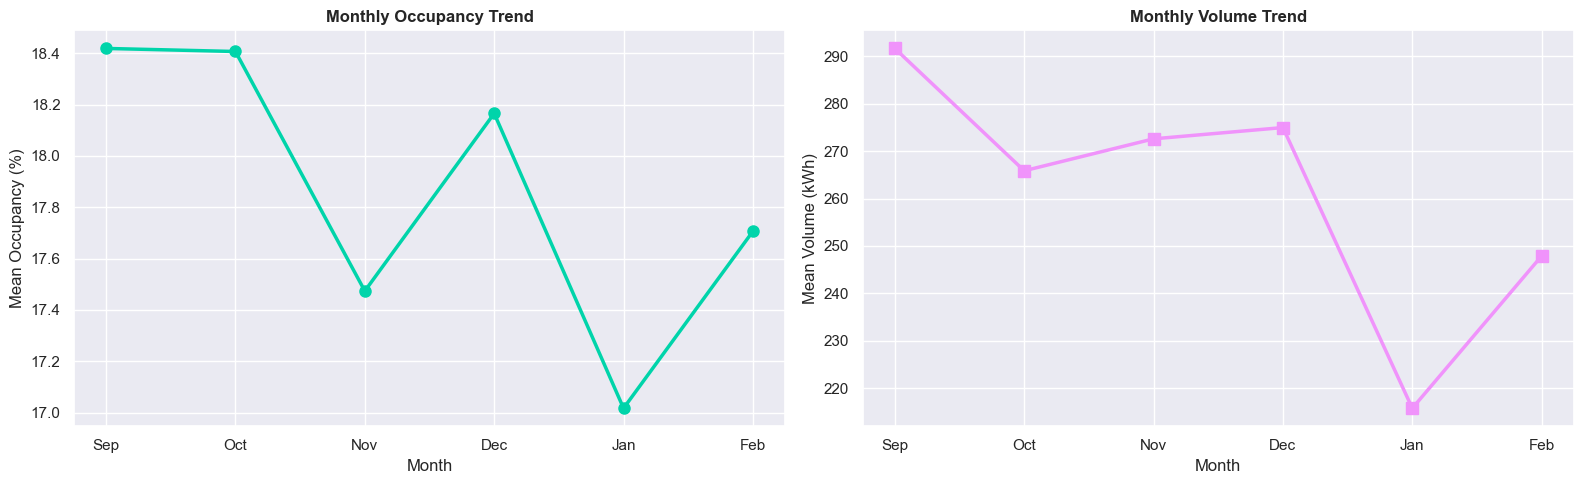

In [10]:
occupancy_long['month'] = pd.to_datetime(occupancy_long['time']).dt.month
volume_long['month'] = pd.to_datetime(volume_long['time']).dt.month
month_order = [9, 10, 11, 12, 1, 2]
month_labels = {9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec', 1:'Jan', 2:'Feb'}
monthly_occ = occupancy_long.groupby('month')['occ'].mean()
monthly_vol = volume_long.groupby('month')['vol'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot([month_labels[m] for m in month_order],
             [monthly_occ[m] for m in month_order],
             marker='o', linewidth=2.5, markersize=8, color='#00d4aa')
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean Occupancy (%)")
axes[0].set_title("Monthly Occupancy Trend", fontweight='bold')

axes[1].plot([month_labels[m] for m in month_order],
             [monthly_vol[m] for m in month_order],
             marker='s', linewidth=2.5, markersize=8, color='#f093fb')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean Volume (kWh)")
axes[1].set_title("Monthly Volume Trend", fontweight='bold')

plt.tight_layout()
plt.show()

#### Chart 5 — Distribution Histograms

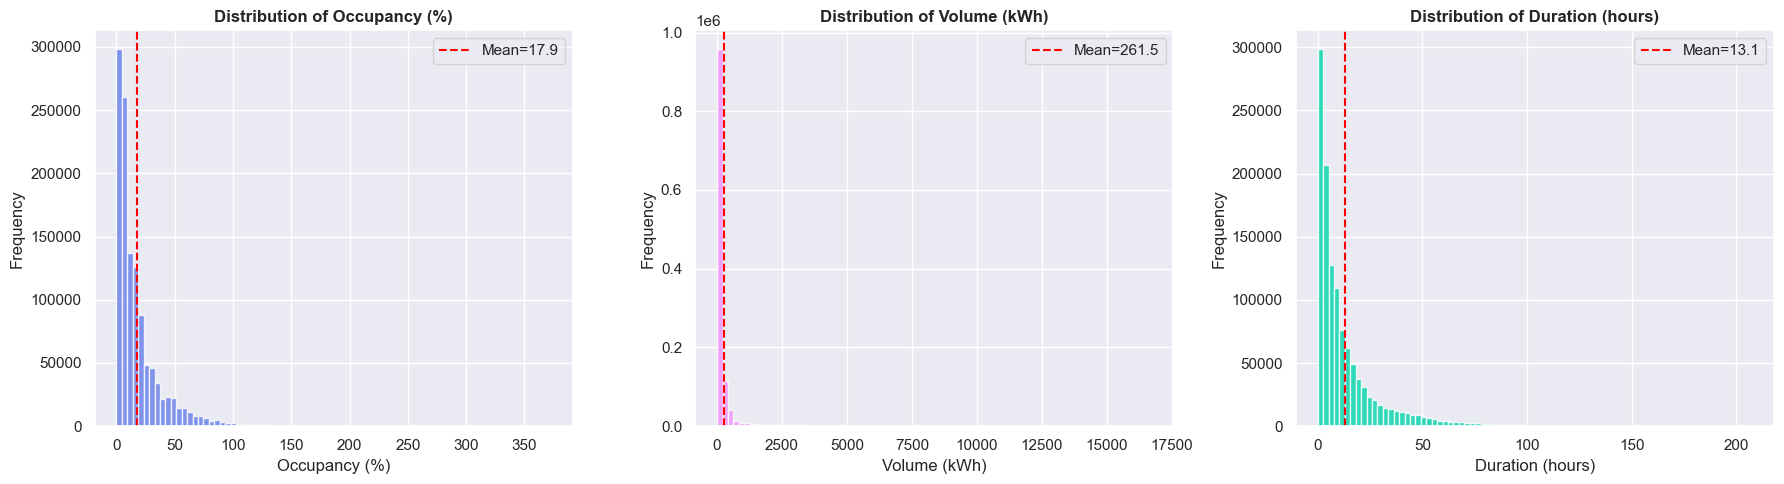

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (values, title, color) in enumerate([
    (occ_values, "Occupancy (%)", "#667eea"),
    (vol_values, "Volume (kWh)", "#f093fb"),
    (dur_values, "Duration (hours)", "#00d4aa"),
]):
    axes[i].hist(values, bins=80, color=color, alpha=0.8, edgecolor='white')
    axes[i].axvline(np.nanmean(values), color='red', ls='--', label=f'Mean={np.nanmean(values):.1f}')
    axes[i].set_title(f"Distribution of {title}", fontweight='bold')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Chart 6 — Correlation Heatmaps

Correlation Matrix (Hourly Means)

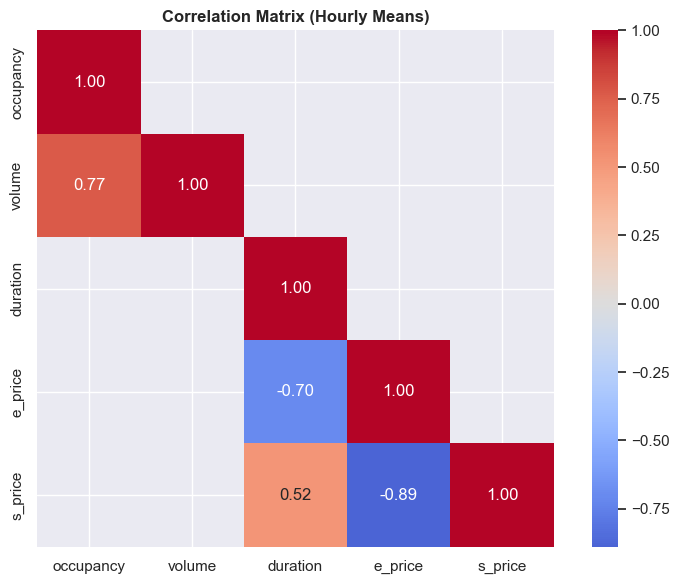

In [12]:
# Compute hourly mean across all zones for each variable
corr_df = pd.DataFrame({
    'occupancy': occupancy.set_index('time').mean(axis=1),
    'volume': volume.set_index('time').mean(axis=1),
    'duration': duration.set_index('time').mean(axis=1),
    'e_price': e_price.set_index('time').iloc[:, :].mean(axis=1),
    's_price': s_price.set_index('time').iloc[:, :].mean(axis=1),
})

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool), k=1)
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f',cmap='coolwarm',
            center=0, square=True, mask=mask, ax=ax)
ax.set_title("Correlation Matrix (Hourly Means)", fontweight='bold')
plt.tight_layout()
plt.show()


Correlation Matrix (Zone-Level Means)

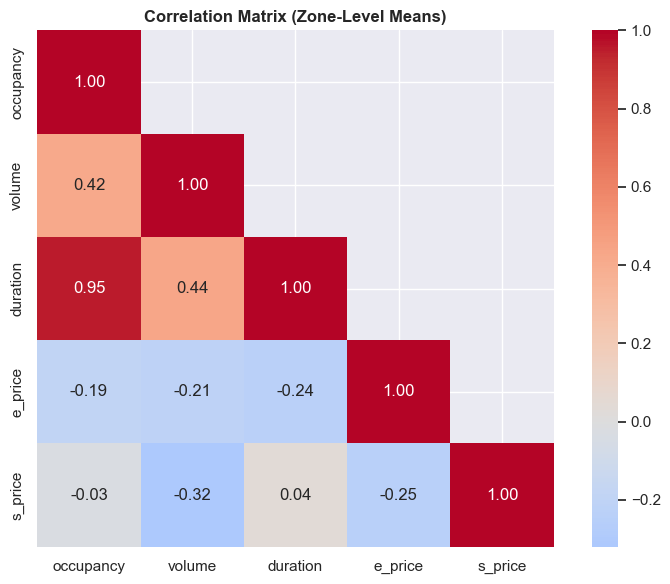

In [13]:
# Compute per-zone mean for each variable and correlate
zone_cols = occupancy.columns[1:]  # zone IDs

corr_data = pd.DataFrame({
    "occupancy": occupancy[zone_cols].mean(),
    "volume":    volume[zone_cols].mean(),
    "duration":  duration[zone_cols].mean(),
    "e_price":   e_price[zone_cols].mean(),
    "s_price":   s_price[zone_cols].mean(),
})

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool), k=1)
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f',cmap='coolwarm',
            center=0, square=True, mask=mask, ax=ax)
ax.set_title("Correlation Matrix (Zone-Level Means)", fontweight='bold')
plt.tight_layout()
plt.show()

#### Chart 7 — Top/Bottom Zones by Demand

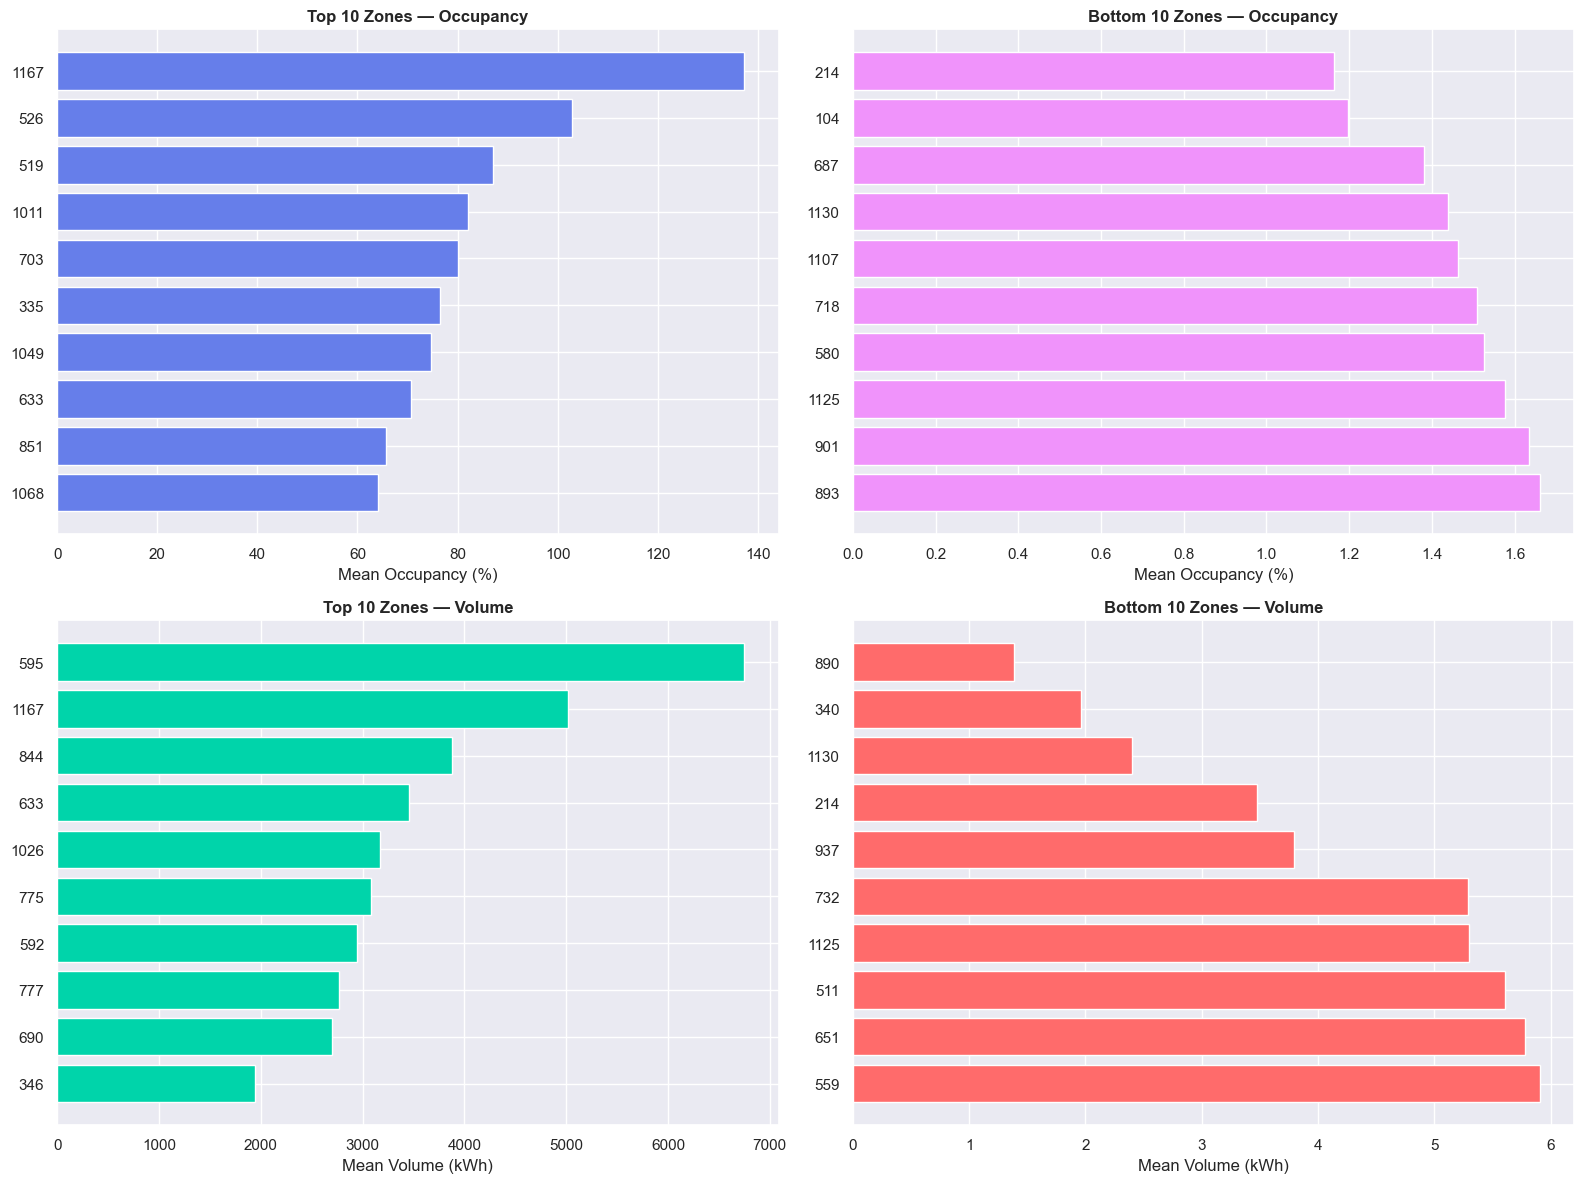

In [14]:
occ_zone_means = occupancy.set_index('time').mean().sort_values(ascending=False)
occ_zone_means.index = occ_zone_means.index.astype(str)

vol_zone_means = volume.set_index('time').mean().sort_values(ascending=False)
vol_zone_means.index = vol_zone_means.index.astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 Occupancy
top10_occ = occ_zone_means.head(10)
axes[0, 0].barh(top10_occ.index[::-1], top10_occ.values[::-1], color='#667eea')
axes[0, 0].set_xlabel("Mean Occupancy (%)")
axes[0, 0].set_title("Top 10 Zones — Occupancy", fontweight='bold')

# Bottom 10 Occupancy
bot10_occ = occ_zone_means.tail(10)
axes[0, 1].barh(bot10_occ.index, bot10_occ.values, color='#f093fb')
axes[0, 1].set_xlabel("Mean Occupancy (%)")
axes[0, 1].set_title("Bottom 10 Zones — Occupancy", fontweight='bold')

# Top 10 Volume
top10_vol = vol_zone_means.head(10)
axes[1, 0].barh(top10_vol.index[::-1], top10_vol.values[::-1], color='#00d4aa')
axes[1, 0].set_xlabel("Mean Volume (kWh)")
axes[1, 0].set_title("Top 10 Zones — Volume", fontweight='bold')

# Bottom 10 Volume
bot10_vol = vol_zone_means.tail(10)
axes[1, 1].barh(bot10_vol.index, bot10_vol.values, color='#ff6b6b')
axes[1, 1].set_xlabel("Mean Volume (kWh)")
axes[1, 1].set_title("Bottom 10 Zones — Volume", fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Zone & Station Metadata Overview

In [15]:
print(f"Total zones: {len(zone_info)}")
print(f"Total stations: {station_info['station_id'].nunique()}")
print(f"Total charging piles: {zone_info['charge_count'].sum()}")
print(f"Zone Info Columns: {zone_info.columns.tolist()}")
print(f"Station Info Columns: {station_info.columns.tolist()}")

print("\nZone Info Statistics")
display(zone_info.describe().round(2))

Total zones: 275
Total stations: 1362
Total charging piles: 23441
Zone Info Columns: ['TAZID', 'longitude', 'latitude', 'charge_count', 'area', 'perimeter']
Station Info Columns: ['station_id', 'longitude', 'latitude', 'charge_count', 'TAZID']

Zone Info Statistics


,TAZID,longitude,latitude,charge_count,area,perimeter
count,275.00,275.00,275.00,275.00,275.00,275.00
mean,733.77,113.64,22.54,85.24,3583954.77,8456.07
std,310.09,6.88,1.37,78.10,5380920.93,6061.33
min,102.00,0.00,0.00,4.00,387839.48,2688.32
25%,527.50,113.92,22.55,28.00,1417430.66,5275.10
50%,737.00,114.04,22.62,58.00,2317791.15,6842.33
75%,1004.50,114.13,22.69,114.50,3761469.95,8850.51
max,1173.00,114.50,22.82,446.00,49933877.00,44371.05


## 7. Key Observations & Takeaways


- **Data completeness:** All 5 hourly datasets have 0% missing values (pre-cleaned by dataset authors using forward/backward filling and IQR outlier treatment)

- **Temporal coverage:** 4,344 hourly timestamps across 275 zones = ~1.19M records per variable

- **Hourly pattern:** Occupancy and volume both peak during daytime hours (~10:00–18:00), with a dip at night — consistent with commuter/work-related charging

- **Day-of-week:** Weekdays show slightly higher occupancy than weekends, suggesting work-commute-driven demand

- **Monthly trend:** Observe any seasonal shifts (e.g., holiday effects in Jan/Feb during Chinese New Year)

- **Distributions:** Occupancy is right-skewed (many low-occupancy periods); volume shows heavy tail (few high-demand events)

- **Correlations:** Occupancy and volume/duration are positively correlated; price variables may show interesting patterns

- **Zone variation:** Large disparity between top and bottom zones — some zones are 10x+ more active, reflecting urban density differences

- **Primary target:** Occupancy (aligned with the published article); Volume as secondary target